<a href="https://colab.research.google.com/github/Lokesh66666/CV_workshop/blob/main/task01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

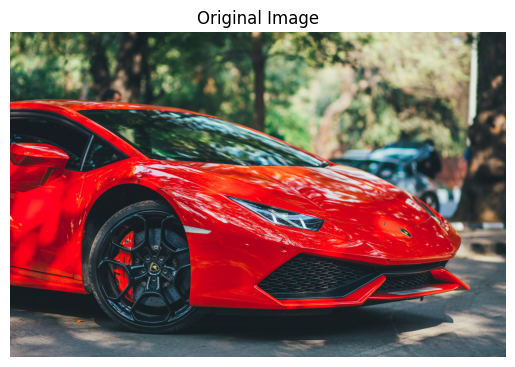

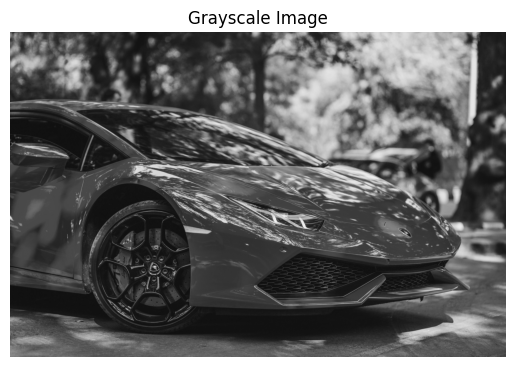

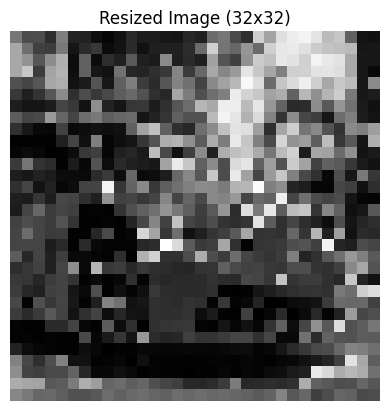

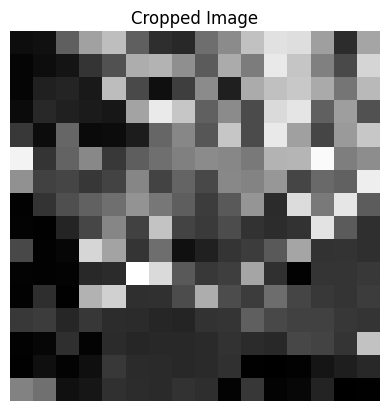

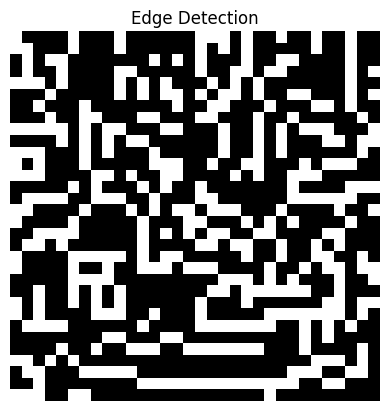

In [8]:
import cv2
import matplotlib.pyplot as plt

# 1. Load your uploaded image
image = cv2.imread('pexels-mohit-hambiria-92377455-31396367.jpg') # Corrected path

# Check if the image was loaded successfully
if image is None:
    print("Error: Could not load image. Please check the file path.")
else:
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Show Original Image
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis('off')
    plt.show()

    # 2. Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    plt.imshow(gray, cmap='gray')
    plt.title("Grayscale Image")
    plt.axis('off')
    plt.show()

    # 3. Resize to 32x32
    resized = cv2.resize(gray, (32, 32))

    plt.imshow(resized, cmap='gray')
    plt.title("Resized Image (32x32)")
    plt.axis('off')
    plt.show()

    # 4. Crop center
    h, w = resized.shape
    cropped = resized[h//4:h//4 + h//2, w//4:w//4 + w//2]

    plt.imshow(cropped, cmap='gray')
    plt.title("Cropped Image")
    plt.axis('off')
    plt.show()

    # 5. Edge detection
    edges = cv2.Canny(resized, 100, 200)

    plt.imshow(edges, cmap='gray')
    plt.title("Edge Detection")
    plt.axis('off')
    plt.show()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 32ms/step - accuracy: 0.9553 - loss: 0.1501 - val_accuracy: 0.9845 - val_loss: 0.0490
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9855 - loss: 0.0472 - val_accuracy: 0.9864 - val_loss: 0.0357
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.9892 - loss: 0.0341 - val_accuracy: 0.9888 - val_loss: 0.0349


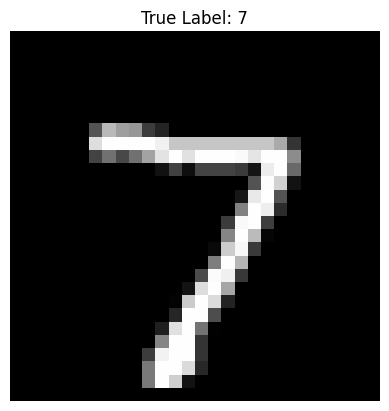

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Predicted Class: 7
Actual Class: 7
Confidence: 0.999998


In [9]:
# Step 1: Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# Step 2: Load Dataset
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Step 3: Normalize
train_images = train_images / 255.0
test_images = test_images / 255.0

# Step 4: Reshape (for CNN)
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

# Step 5: Build CNN Model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Step 6: Compile Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Step 7: Train Model
model.fit(train_images, train_labels, epochs=3, validation_data=(test_images, test_labels))

# Step 8: Select One Test Image
index = 0
test_img = test_images[index]
true_label = test_labels[index]

# Step 9: Display Image
plt.imshow(test_img.squeeze(), cmap='gray')
plt.title(f"True Label: {true_label}")
plt.axis('off')
plt.show()

# Step 10: Prepare Image
input_img = np.expand_dims(test_img, axis=0)

# Step 11: Predict
prediction = model.predict(input_img)

# Step 12: Output
predicted_class = np.argmax(prediction)
confidence = np.max(prediction)

print("Predicted Class:", predicted_class)
print("Actual Class:", true_label)
print("Confidence:", confidence)

In [5]:
from google.colab import files
uploaded = files.upload()

Saving pexels-mohit-hambiria-92377455-31396367.jpg to pexels-mohit-hambiria-92377455-31396367 (1).jpg
